# Clustering

#### Objective

The objective of this project is to perform customer segmentation
using clustering techniques.

The algorithms used are:

• K-Means Clustering
• DBSCAN

The performance of both algorithms is evaluated using
the Silhouette Score to identify the better clustering method.

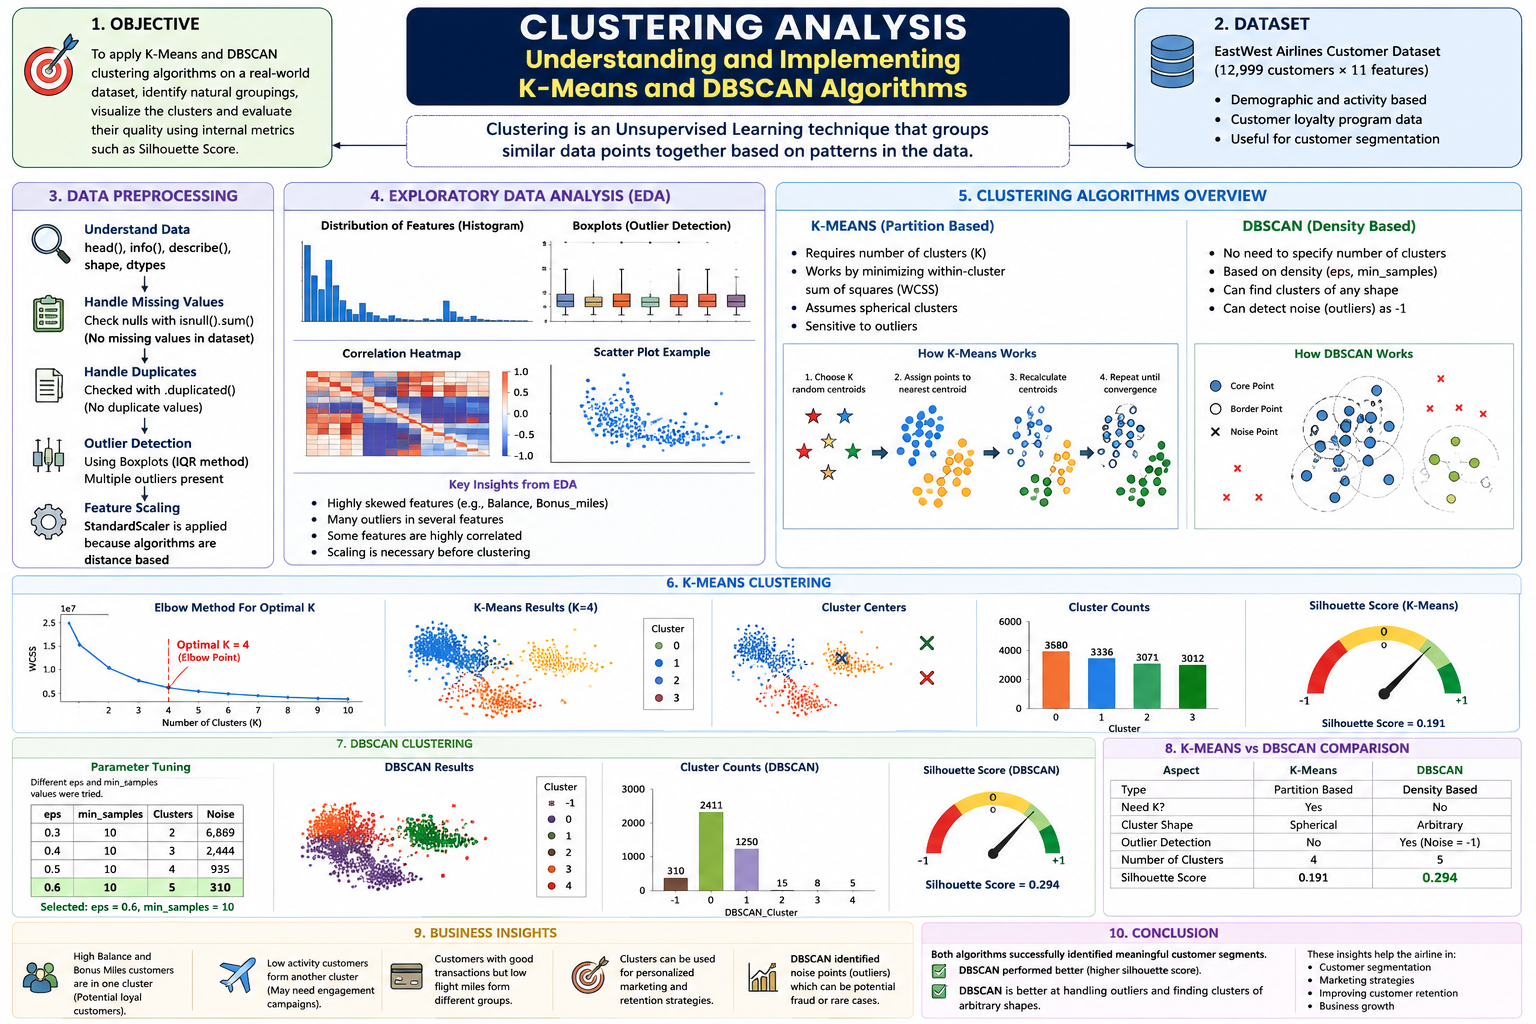

In [2]:
import numpy as np
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Ignore unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")

In [5]:
# ==========================================
# Load the Excel File
# ==========================================

# Read the Excel file
excel_file = pd.ExcelFile("EastWestAirlines.xlsx")

# Display all sheet names
excel_file.sheet_names

['Description', 'data']

In [6]:
df = pd.read_excel("EastWestAirlines.xlsx", sheet_name="data")

In [7]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


| Feature           | Meaning                                   |
| ----------------- | ----------------------------------------- |
| Balance           | Customer's frequent flyer balance         |
| Qual_miles        | Qualifying miles earned                   |
| cc1_miles         | Credit card category                      |
| cc2_miles         | Credit card category                      |
| cc3_miles         | Credit card category                      |
| Bonus_miles       | Bonus miles earned                        |
| Bonus_trans       | Bonus transactions                        |
| Flight_miles_12mo | Flight miles in last 12 months            |
| Flight_trans_12   | Flights in last 12 months                 |
| Days_since_enroll | Customer loyalty duration                 |
| Award?            | Whether customer received an award ticket |


In [8]:
df.shape

(3999, 12)

In [9]:

df.columns

Index(['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')

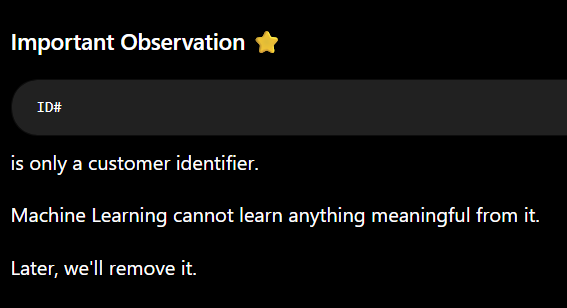

In [10]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [11]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


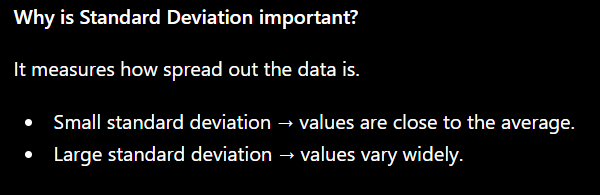

In [12]:
df.isnull().sum()

,0
ID#,0
Balance,0
Qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
Bonus_miles,0
Bonus_trans,0
Flight_miles_12mo,0
Flight_trans_12,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:

# Remove Customer ID


# ID# is only an identifier.
# It doesn't provide any meaningful information
# for clustering.

df = df.drop("ID#", axis=1)

# Display first few rows
df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


In [15]:

# Separate Numerical and Categorical Columns


# Select all numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns

# Select all categorical columns
categorical_columns = df.select_dtypes(exclude=np.number).columns

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')

Categorical Columns:
Index([], dtype='object')


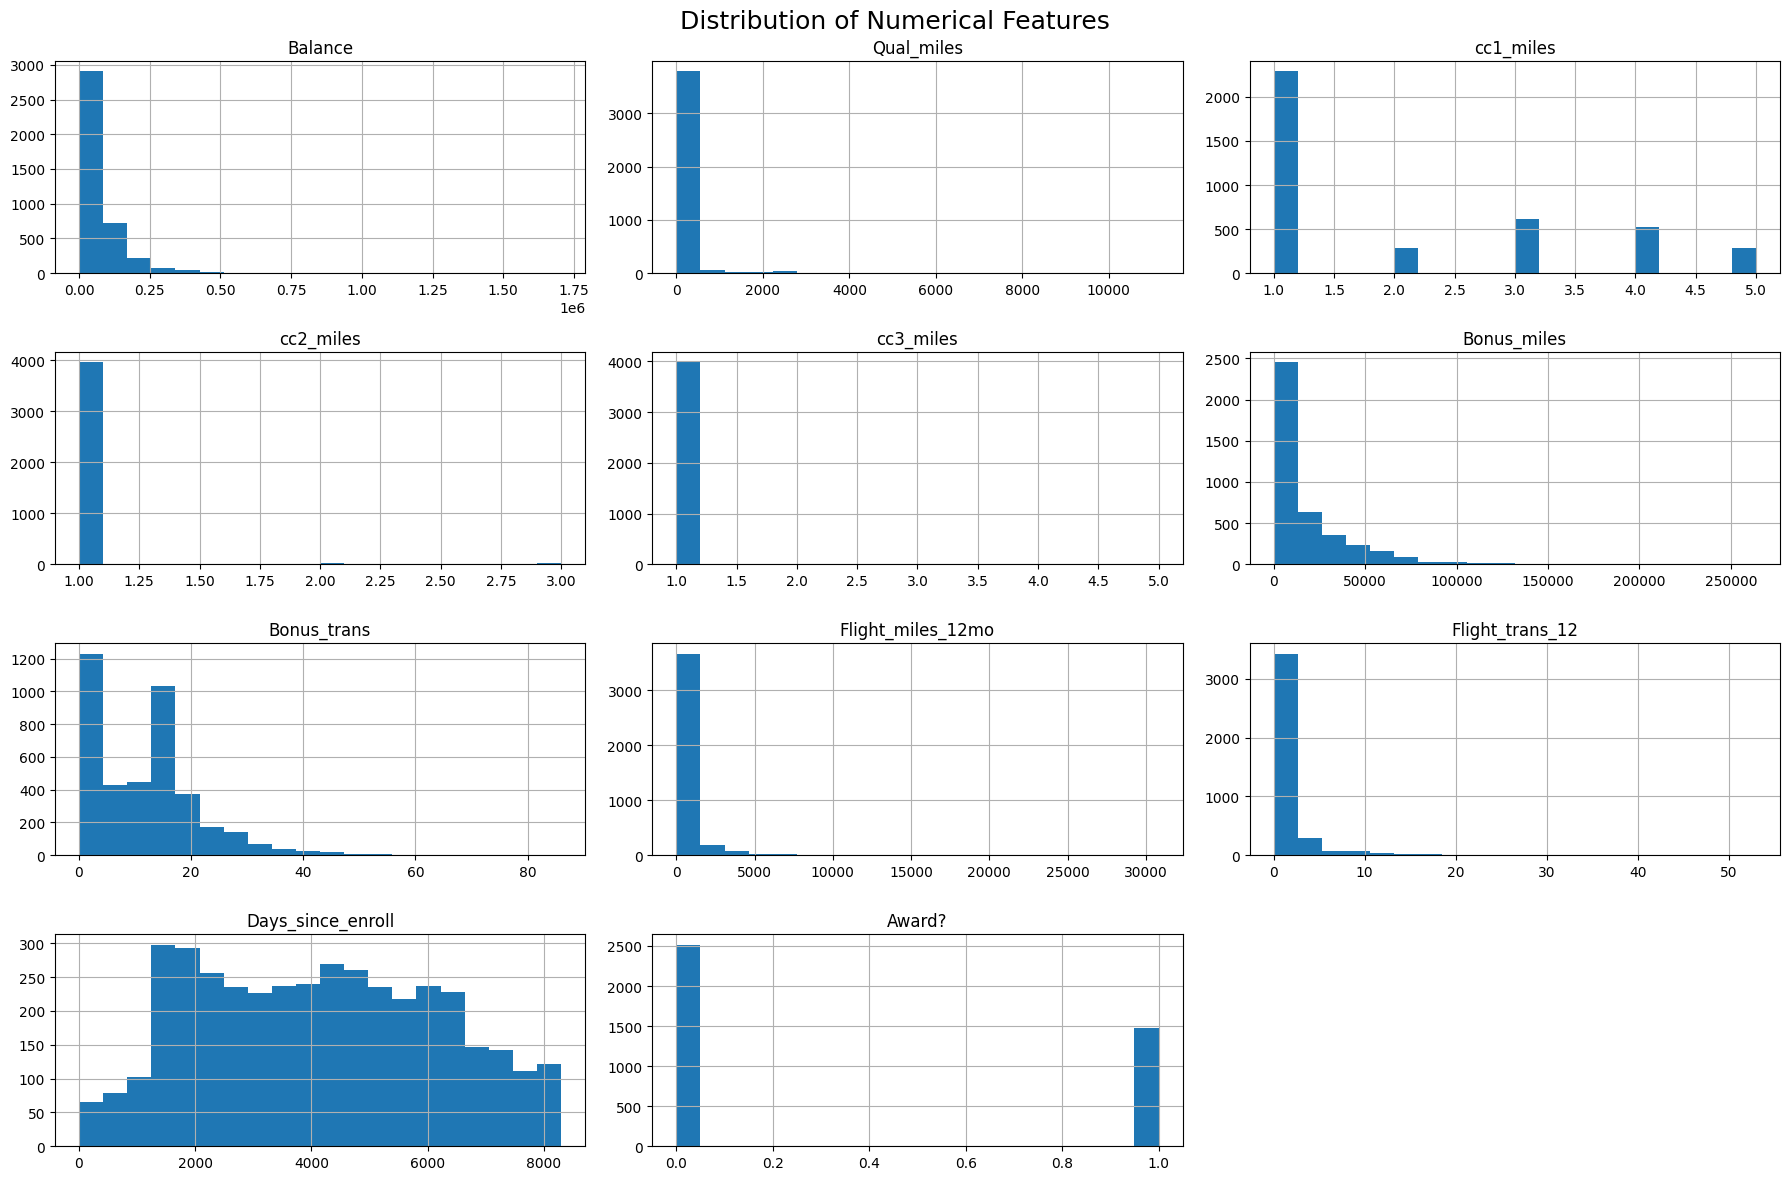

In [16]:

# Distribution of Numerical Features


# Histograms show how the values are distributed.

df.hist(
    figsize=(18,12),
    bins=20
    )

plt.suptitle("Distribution of Numerical Features", fontsize=18)

plt.tight_layout()

plt.show()

Observation

Most numerical features are right-skewed.

Several features contain high-value observations,
indicating the presence of potential outliers.

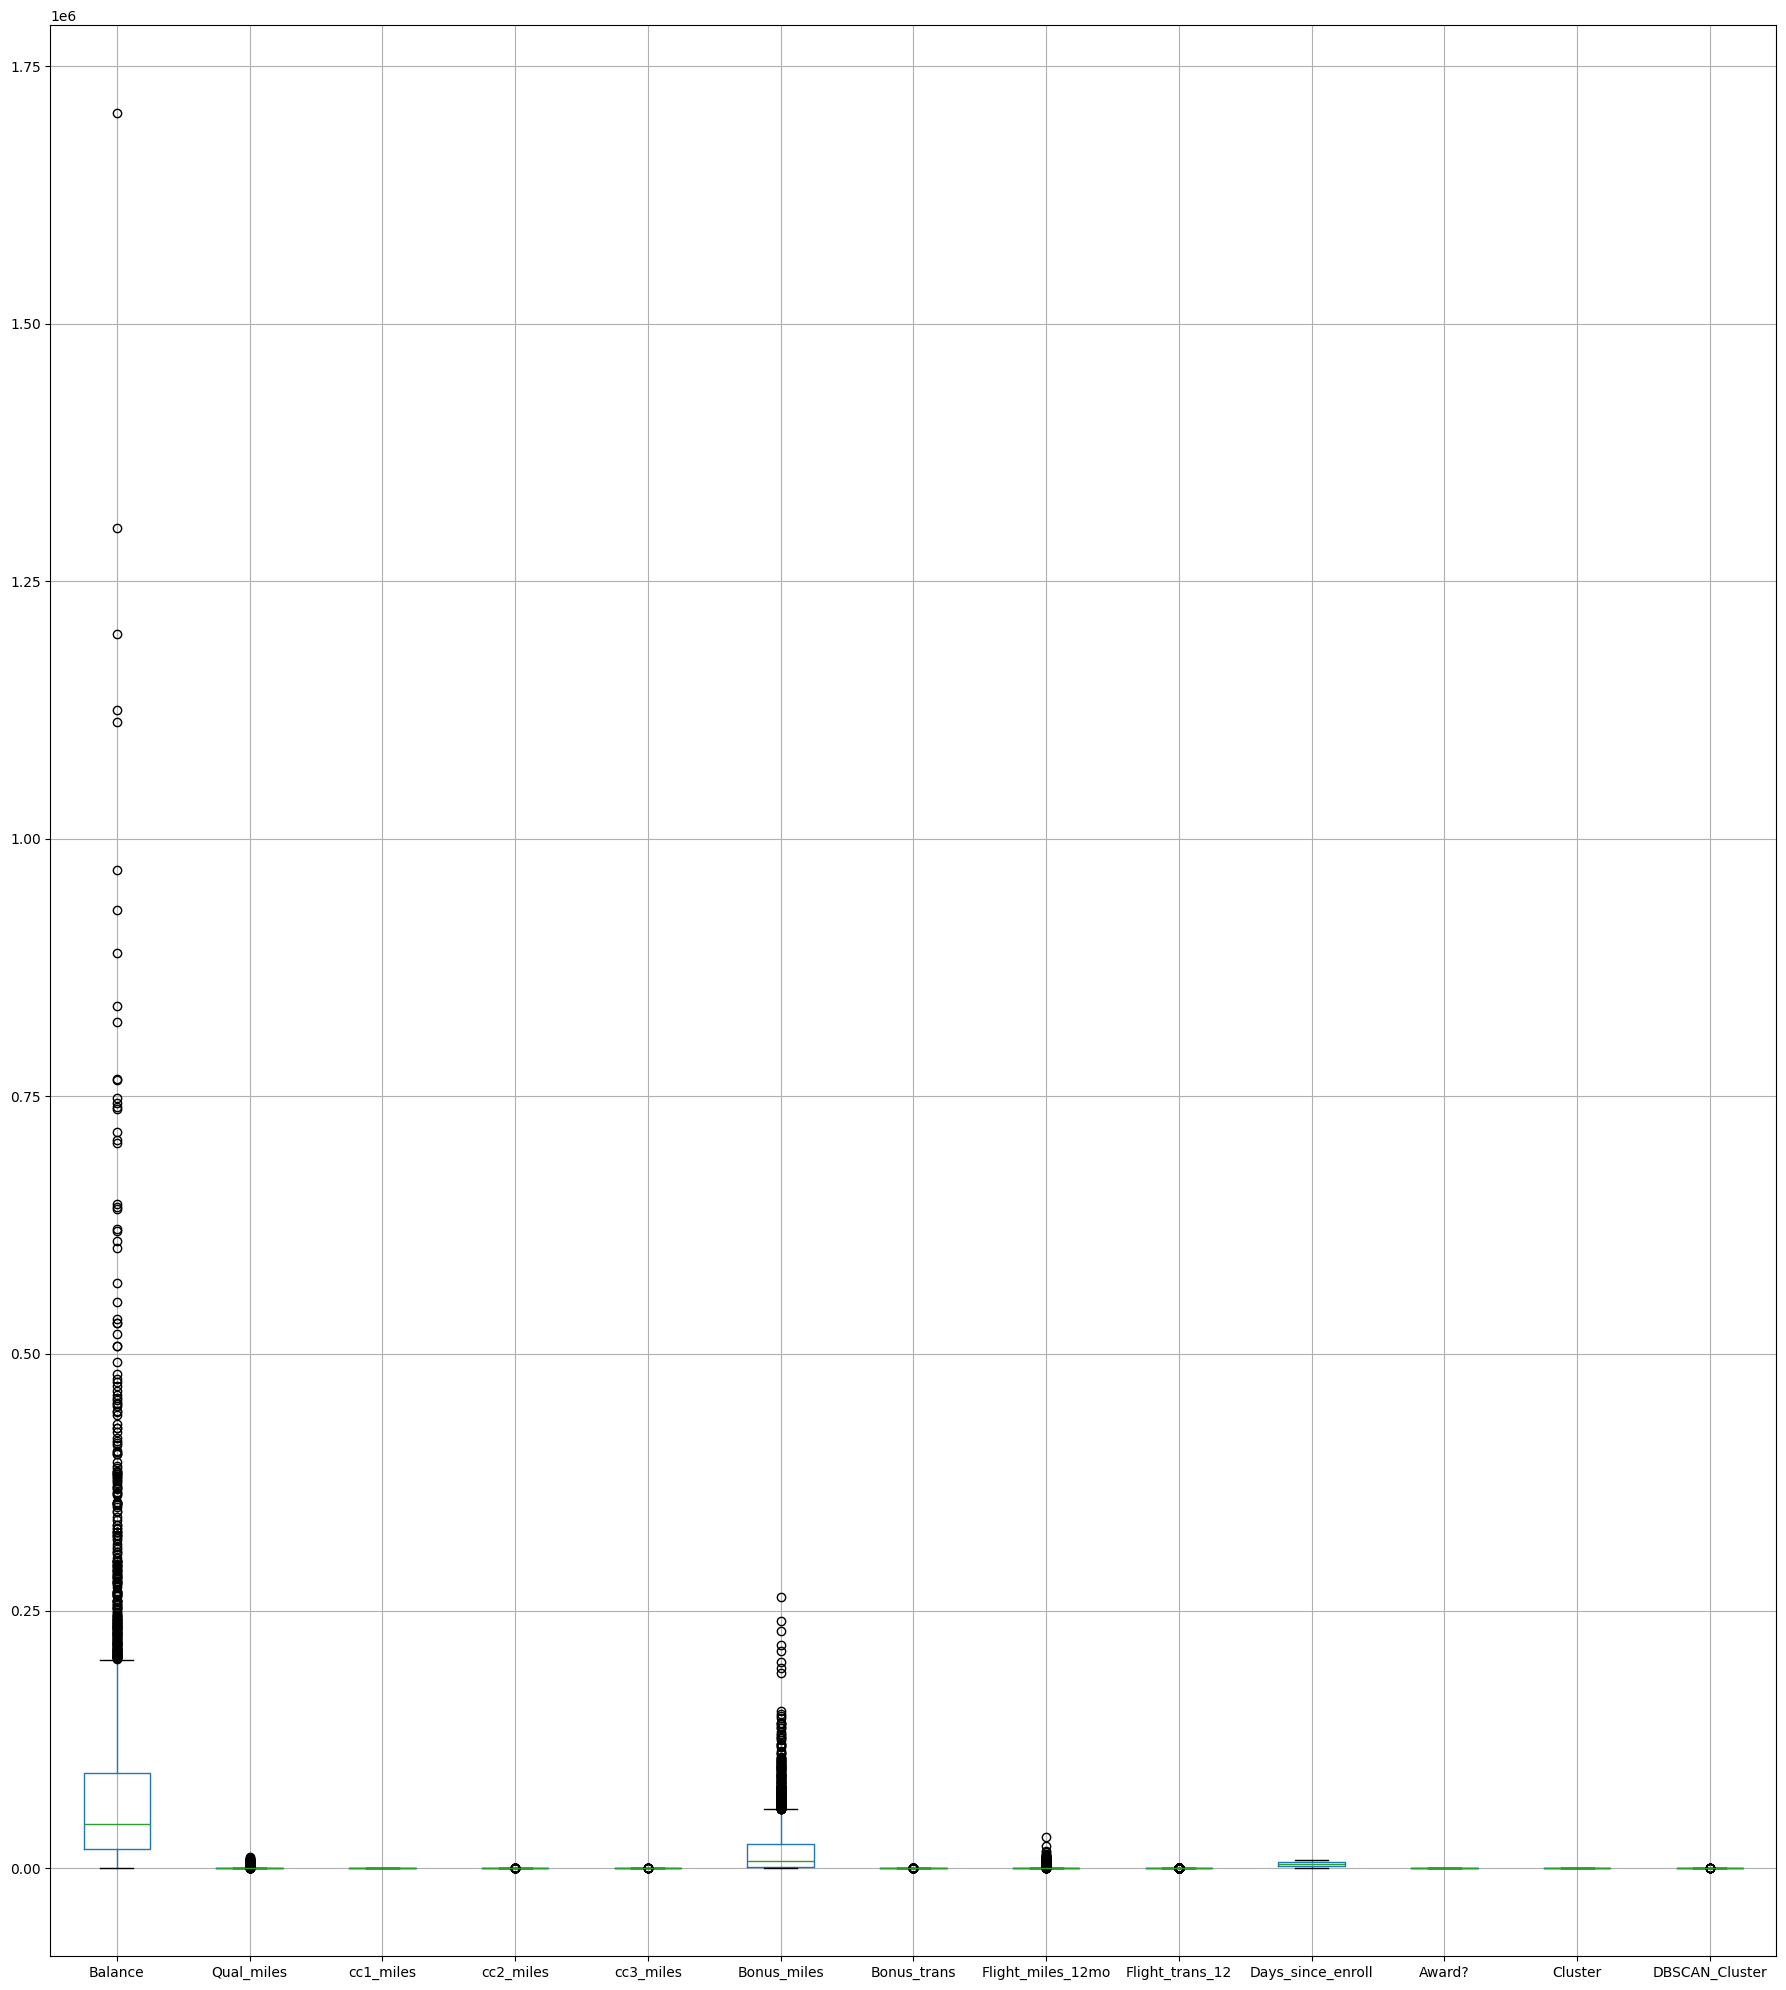

In [43]:
df.boxplot(
    figsize=(18,20),

)

plt.tight_layout()
plt.show()

Many variables have outliers.

Some variables have extremely large values, causing the scale of the graph to stretch.

Because of this, the smaller variables look almost like a straight line near the bottom.

This happens because features such as Balance and Bonus_miles have values in the hundreds of thousands or even millions, while others like Award? only have values 0 and 1.

for my study and learning how the flow of different codes i used the below  cells kindly ingore them

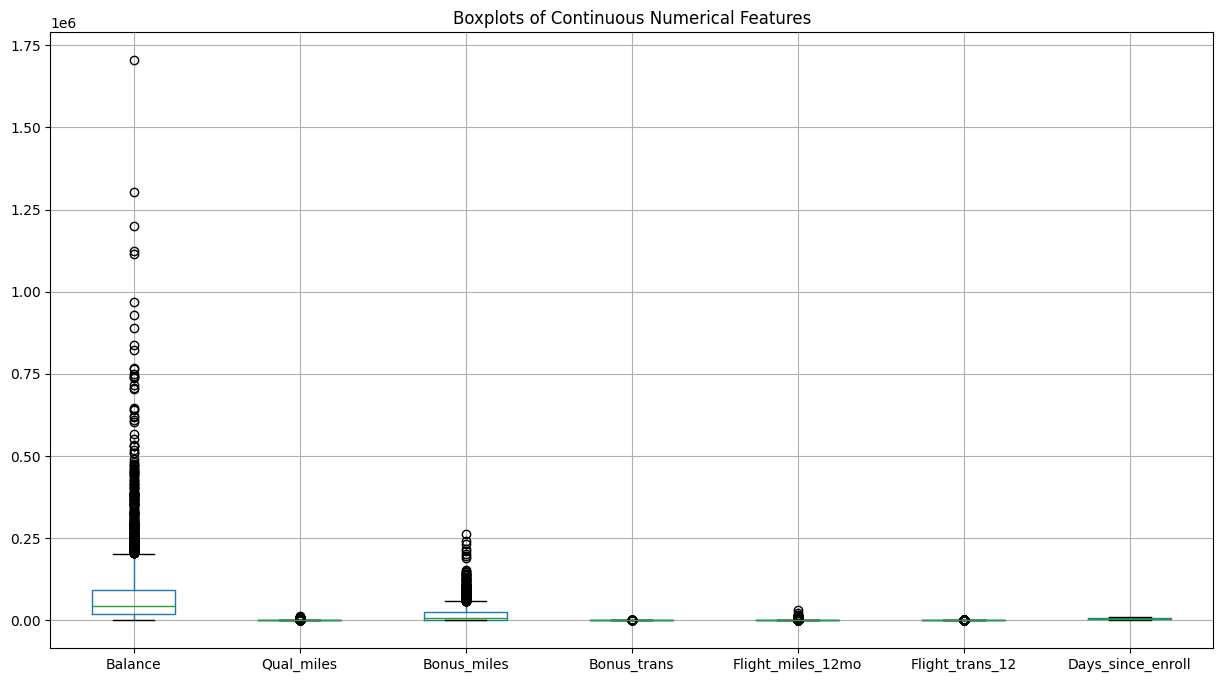

In [44]:
continuous_columns = [
    'Balance',
    'Qual_miles',
    'Bonus_miles',
    'Bonus_trans',
    'Flight_miles_12mo',
    'Flight_trans_12',
    'Days_since_enroll'
]

df[continuous_columns].boxplot(figsize=(15,8))
plt.title("Boxplots of Continuous Numerical Features")
plt.show()

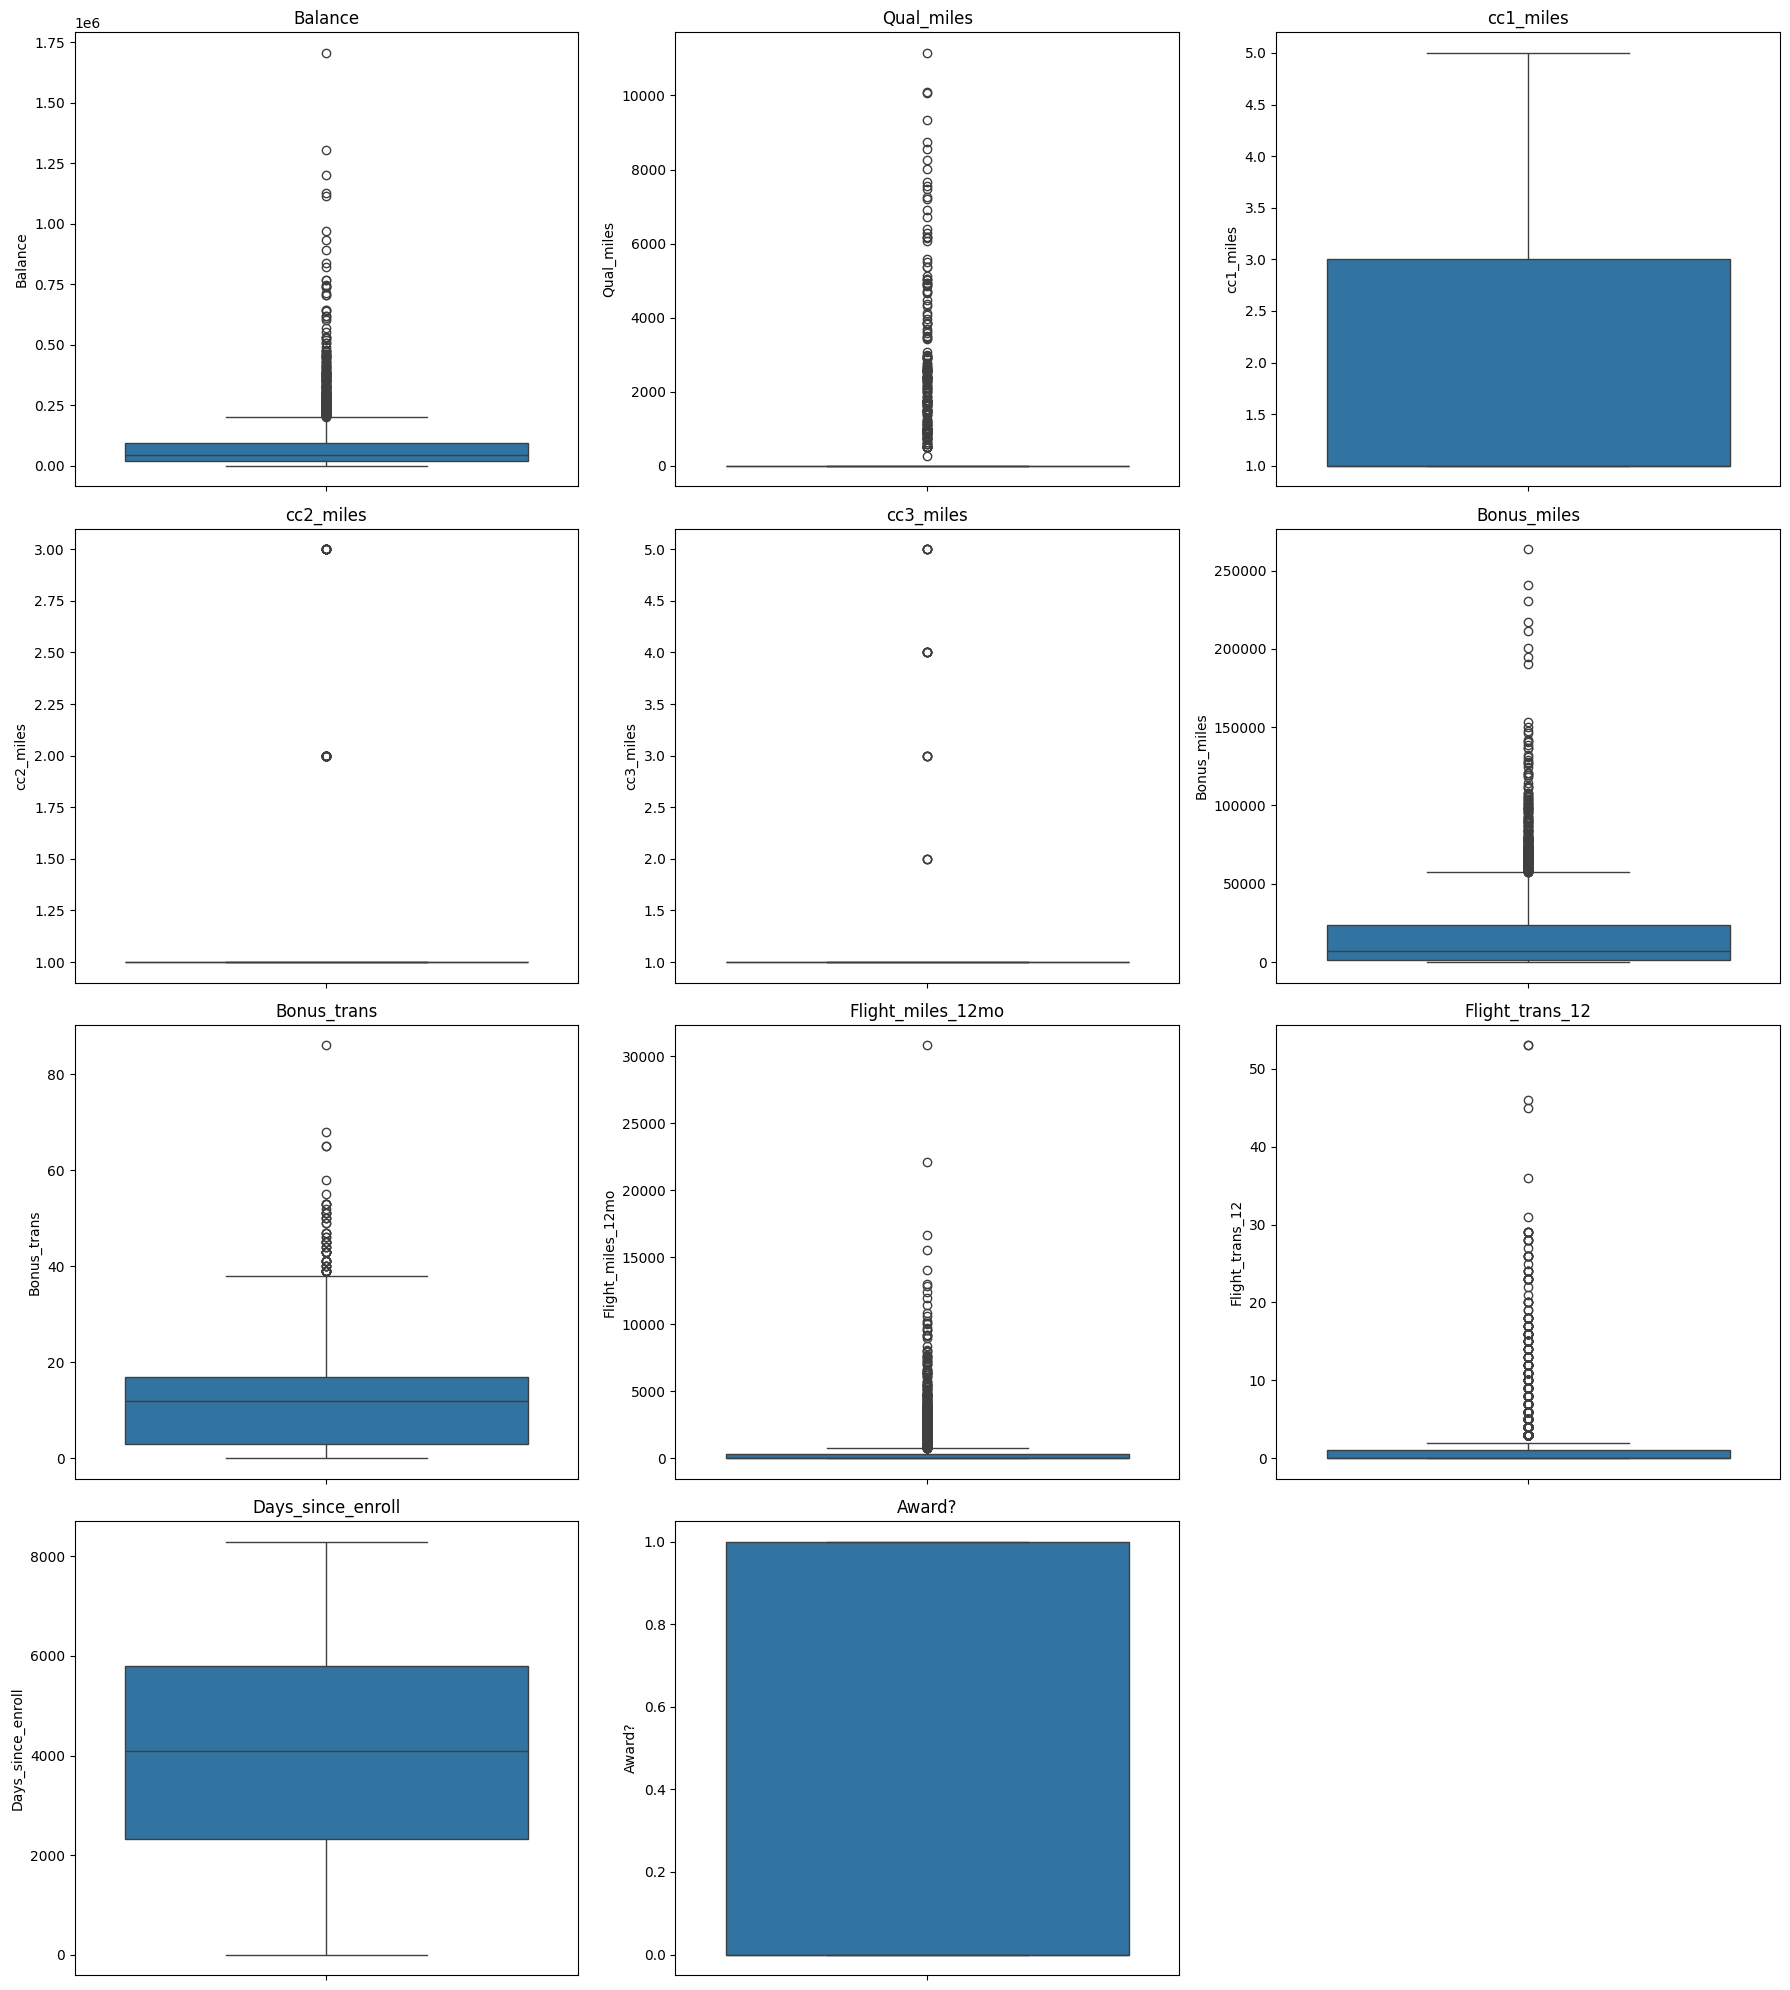

In [17]:

# Boxplots for Outlier Detection


plt.figure(figsize=(18,20))

for i, col in enumerate(numerical_columns):

    plt.subplot(4,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()


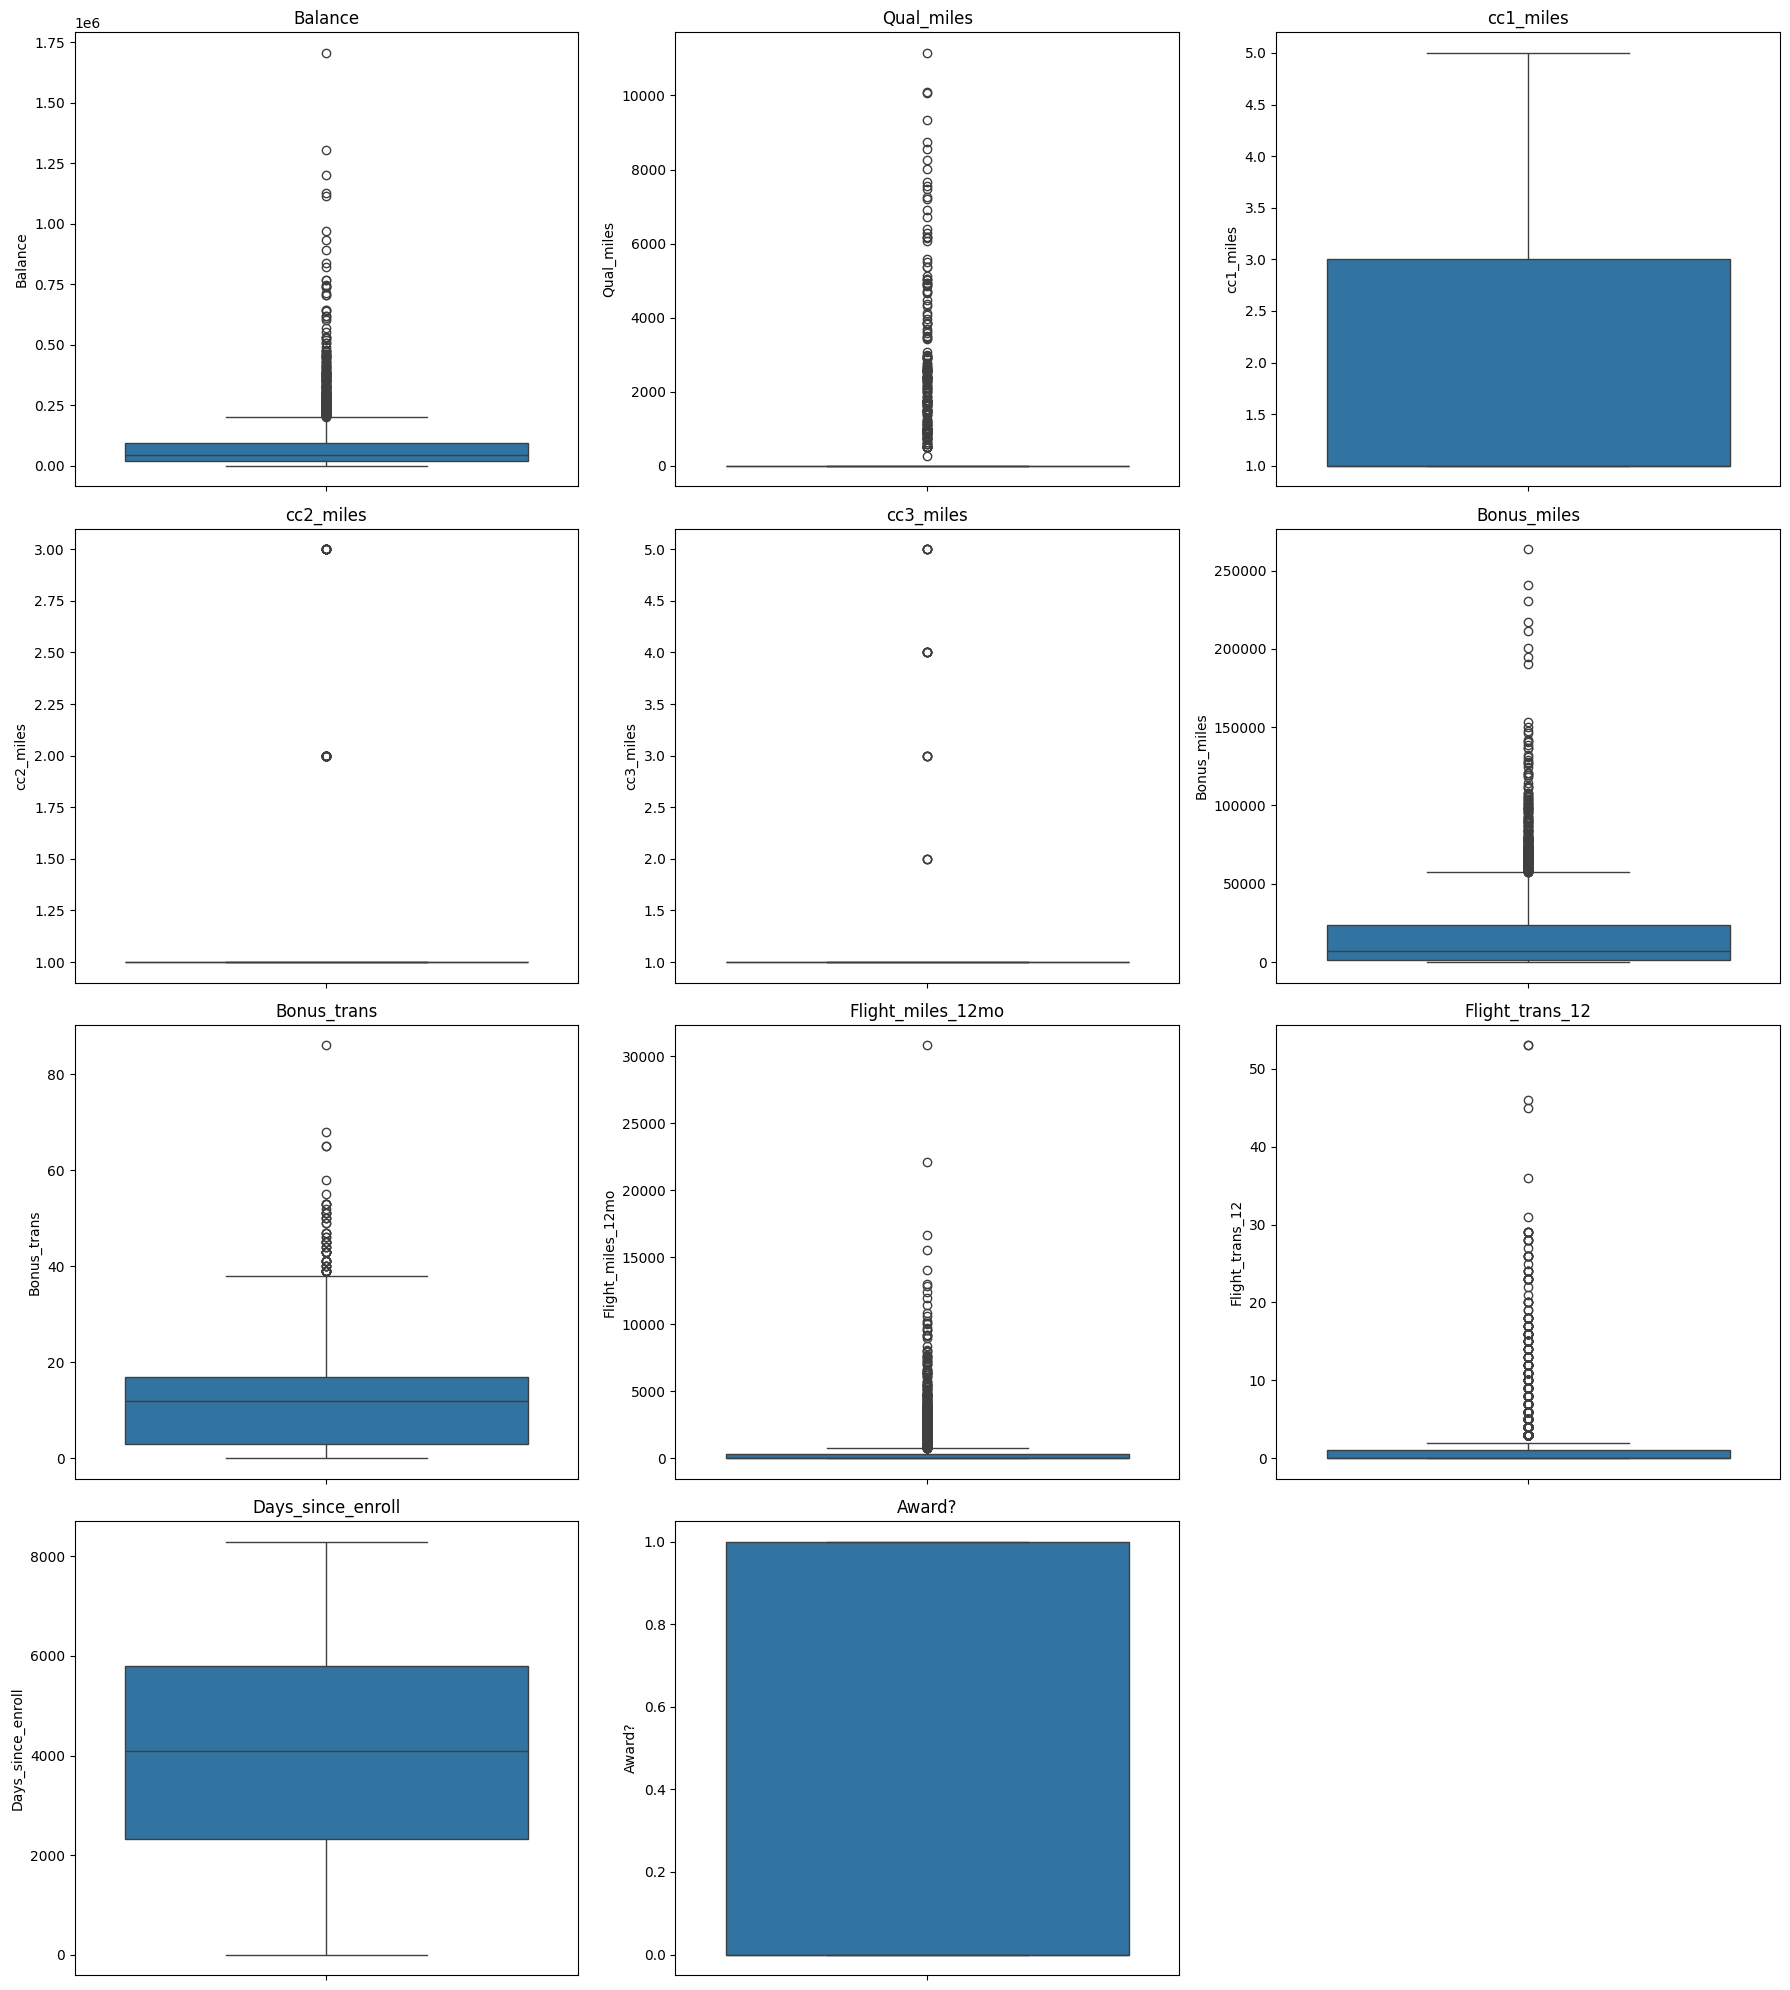

In [18]:

# Boxplots for Outlier Detection


plt.figure(figsize=(18,20))

plot_number = 1

for col in numerical_columns:

    plt.subplot(4, 3, plot_number)

    sns.boxplot(y=df[col])

    plt.title(col)

    plot_number = plot_number + 1

plt.tight_layout()

plt.show()

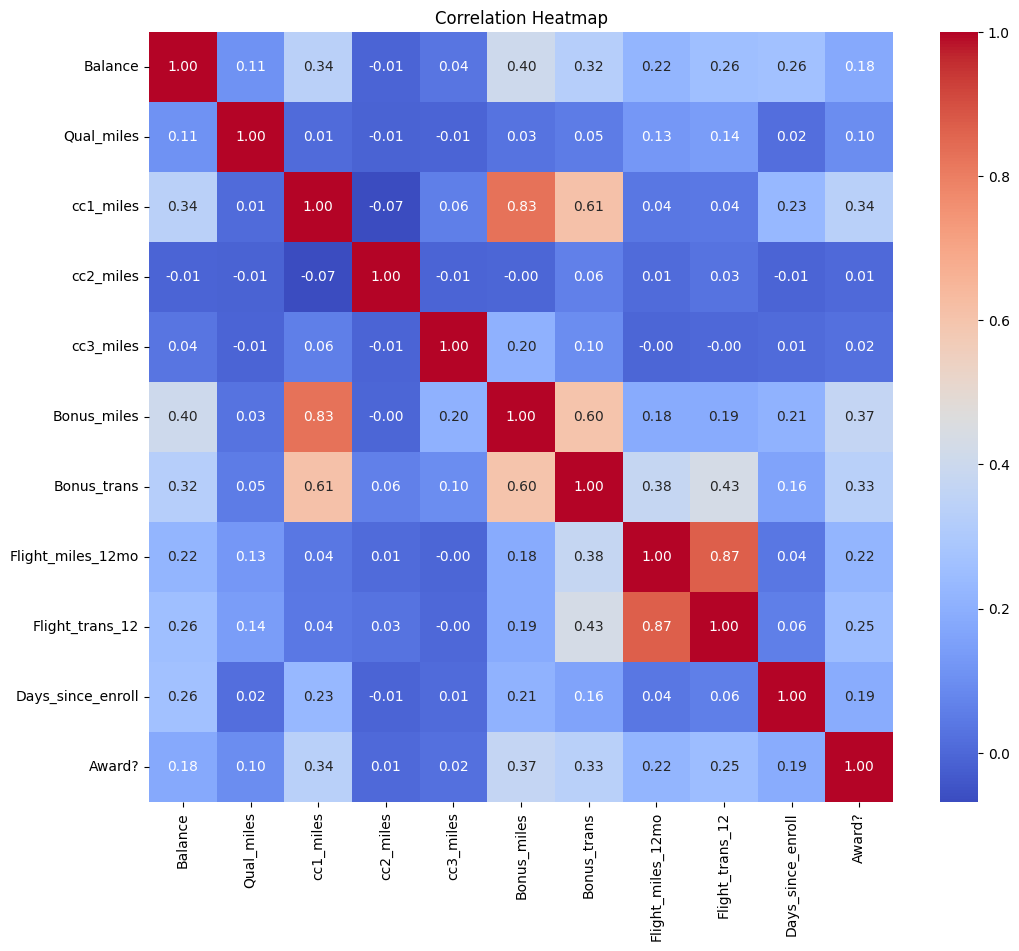

In [19]:

# Correlation Heatmap


plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

 Observation

Some variables show positive correlation,
while others have weak relationships.

Feature scaling is still required because
clustering algorithms depend on distance calculations.

In [20]:

# Feature Scaling


from sklearn.preprocessing import StandardScaler

# Create the scaler object
scaler = StandardScaler()

# Learn the mean and standard deviation of each feature
# and transform the data into the scaled version.
df_scaled = scaler.fit_transform(df)

# Convert the NumPy array back into a DataFrame
# so we keep the original column names.
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

# Display the first five rows
df_scaled.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.451141,-0.186299,-0.769578,-0.098242,-0.062767,-0.702786,-1.104065,-0.328603,-0.362168,1.395454,-0.766919
1,-0.539457,-0.186299,-0.769578,-0.098242,-0.062767,-0.701088,-0.999926,-0.328603,-0.362168,1.379957,-0.766919
2,-0.320031,-0.186299,-0.769578,-0.098242,-0.062767,-0.539253,-0.791649,-0.328603,-0.362168,1.411920,-0.766919
3,-0.583799,-0.186299,-0.769578,-0.098242,-0.062767,-0.689286,-1.104065,-0.328603,-0.362168,1.372208,-0.766919
4,0.239678,-0.186299,1.409471,-0.098242,-0.062767,1.083121,1.499394,1.154932,0.692490,1.363975,1.303918


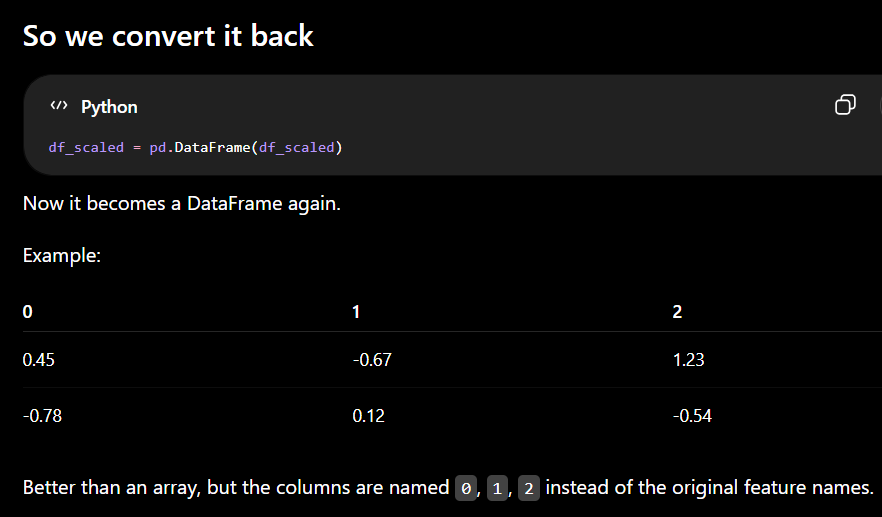

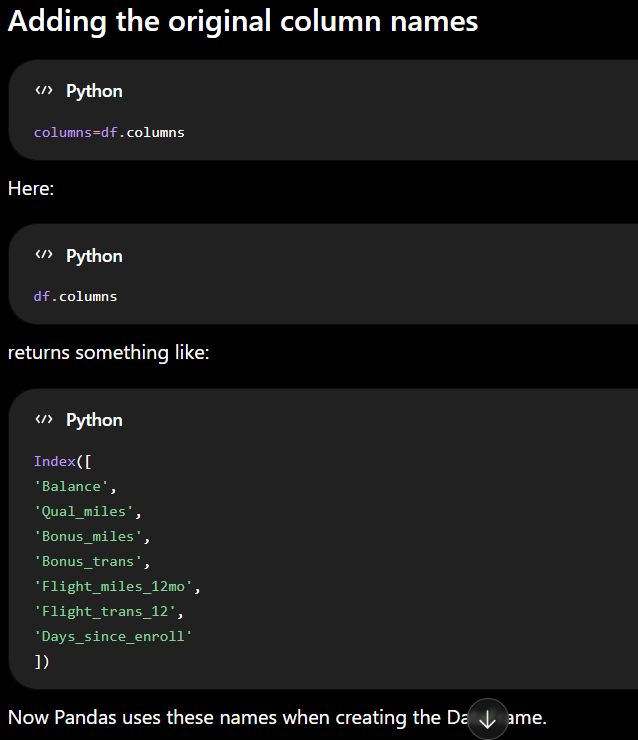

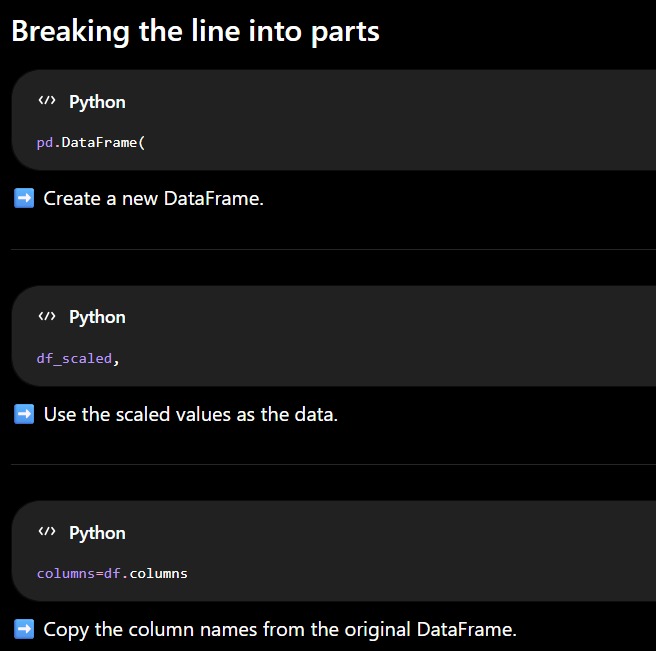

In [21]:
pd.DataFrame(df_scaled, columns=df.columns)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.451141,-0.186299,-0.769578,-0.098242,-0.062767,-0.702786,-1.104065,-0.328603,-0.362168,1.395454,-0.766919
1,-0.539457,-0.186299,-0.769578,-0.098242,-0.062767,-0.701088,-0.999926,-0.328603,-0.362168,1.379957,-0.766919
2,-0.320031,-0.186299,-0.769578,-0.098242,-0.062767,-0.539253,-0.791649,-0.328603,-0.362168,1.411920,-0.766919
3,-0.583799,-0.186299,-0.769578,-0.098242,-0.062767,-0.689286,-1.104065,-0.328603,-0.362168,1.372208,-0.766919
4,0.239678,-0.186299,1.409471,-0.098242,-0.062767,1.083121,1.499394,1.154932,0.692490,1.363975,1.303918
...,...,...,...,...,...,...,...,...,...,...,...
3994,-0.547079,-0.186299,-0.769578,-0.098242,-0.062767,-0.356960,-0.791649,-0.185750,-0.098503,-1.315120,1.303918
3995,-0.091465,-0.186299,-0.769578,-0.098242,-0.062767,-0.669367,-0.687511,-0.328603,-0.362168,-1.318994,1.303918
3996,-0.000043,-0.186299,0.683121,-0.098242,-0.062767,0.343804,-0.375096,-0.328603,-0.362168,-1.315604,1.303918
3997,-0.185607,-0.186299,-0.769578,-0.098242,-0.062767,-0.689286,-1.104065,0.028531,-0.098503,-1.316088,-0.766919


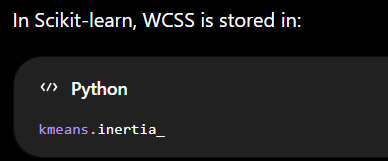

In [47]:

# Elbow Method


from sklearn.cluster import KMeans

# Store WCSS values for different K values
wcss = []

# Try K values from 1 to 10
for k in range(1, 11):

    # Create K-Means model
    kmeans = KMeans(
        n_clusters=k,  # using a default value k
        random_state=42
    )

    # Train the model
    kmeans.fit(df_scaled) # see we are using the sacled data

    # Store the WCSS (Within Cluster Sum of Squares)
    wcss.append(kmeans.inertia_)

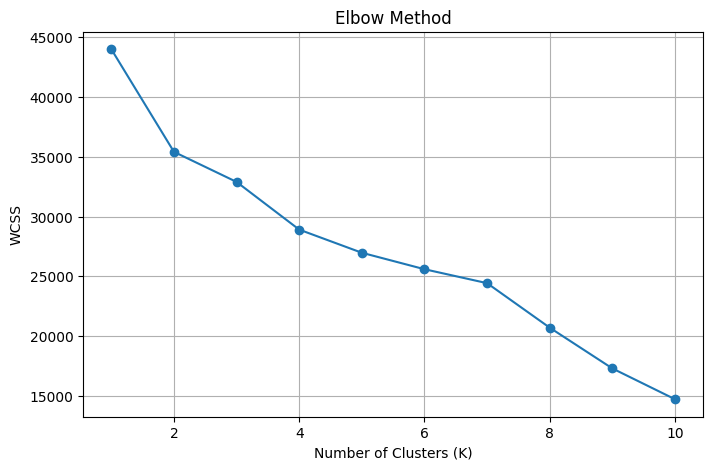

In [23]:

# Elbow Curve


plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o",
    linestyle="-"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

we used the elbow method and curve as we we know how many clusters we need to create

In [45]:

# Build the Final K-Means Model


# Create the K-Means model with 4 clusters
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

# Train the model using the scaled data
kmeans.fit(df_scaled)

# Display the model
kmeans

KMeans(n_clusters=4, random_state=42)

In [25]:

# Cluster Labels


# labels_ stores the cluster number assigned
# to every customer.

kmeans.labels_

array([2, 2, 2, ..., 3, 3, 3], dtype=int32)

In [48]:

# Add Cluster Labels to the Dataset


# Create a new column called 'Cluster'
# and store the cluster assigned to each customer.

df["Cluster"] = kmeans.labels_   # simple example to remember labels is types of alcohols

# Display the first five rows
df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,Cluster,DBSCAN_Cluster
0,28143,0,1,1,1,174,1,0,0,7000,0,2,0
1,19244,0,1,1,1,215,2,0,0,6968,0,2,0
2,41354,0,1,1,1,4123,4,0,0,7034,0,2,0
3,14776,0,1,1,1,500,1,0,0,6952,0,2,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1,1,1


In [27]:

# Number of Customers in Each Cluster


# Count how many customers belong
# to each cluster.

df["Cluster"].value_counts()

,count
Cluster,
3,1502
2,1236
1,1105
0,156


In [49]:

# Cluster Centers
# ==========================================

# Display the center (average point)


cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=df_scaled.columns # we normally see df,columns in crating a dataframe and here we use df_scaled as we used the df_scaled data
)

cluster_centers

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.160959,-0.060609,-0.315018,-0.098242,-0.062767,-0.300875,-0.159759,-0.028002,-0.017032,0.042429,1.303918
1,0.176086,-0.072950,1.527331,-0.098242,-0.053101,1.359180,0.937047,-0.000276,0.013430,0.452572,1.264846
2,-0.259339,-0.140566,-0.687181,-0.098242,-0.056450,-0.583311,-0.574769,-0.200378,-0.220420,0.727378,-0.766919
3,-0.418683,-0.137974,-0.697526,-0.098242,-0.062767,-0.586467,-0.617494,-0.219106,-0.242488,-1.034335,-0.766919
4,0.563882,0.407769,0.045712,-0.098242,-0.062767,0.586360,1.880881,4.529383,4.663601,0.121854,0.817905
5,0.351499,-0.164780,0.984466,-0.098242,-0.054300,0.478777,0.626354,-0.197877,-0.224888,0.139879,-0.766919
6,0.639719,-0.084433,1.022084,-0.098242,15.646299,3.179691,1.714614,0.033293,0.059695,0.239873,0.337527
7,4.667552,0.182712,1.277407,-0.098242,-0.062767,2.237142,1.134234,0.709238,0.952731,1.004909,0.981190
8,-0.046890,-0.156236,-0.668227,9.038254,-0.062767,-0.101665,0.617851,0.087549,0.220347,-0.072464,0.051784
9,0.425464,7.099877,0.009597,-0.098242,-0.062767,0.110131,0.098260,0.359263,0.400062,-0.081324,0.324977


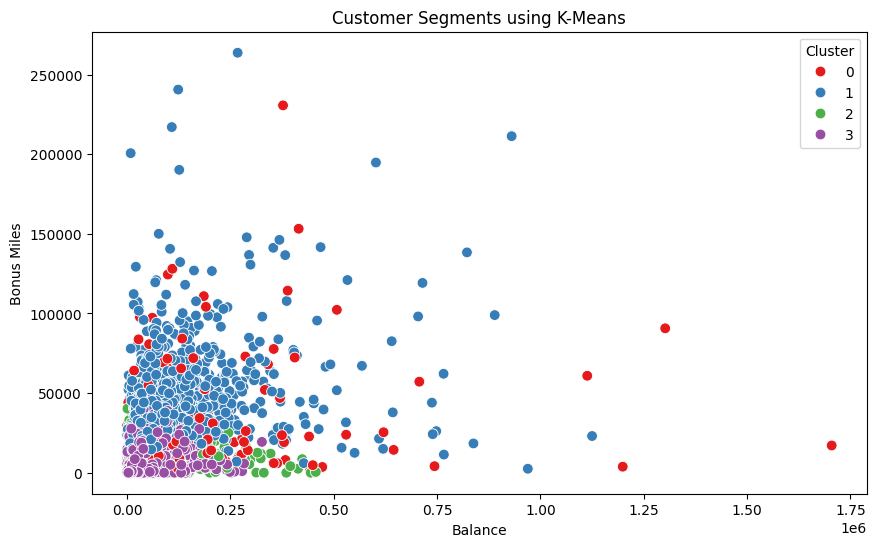

In [29]:

# Visualize the Clusters


plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Balance",
    y="Bonus_miles",
    hue="Cluster",
    palette="Set1",
    s=60
)

plt.title("Customer Segments using K-Means")
plt.xlabel("Balance")
plt.ylabel("Bonus Miles")

plt.show()


 Business Interpretation of Clusters :


 Cluster 0:

 Premium / VIP Customers

 High balance, high flight activity, high bonus miles.

 Cluster 1:

 Regular Active Customers

 Moderate flight activity and good engagement.

 Cluster 2:

 Average Customers

 Moderate balance with lower activity.

 Cluster 3:

 Low Activity Customers

 Low balance and minimal flight activity.

In [30]:
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score
)

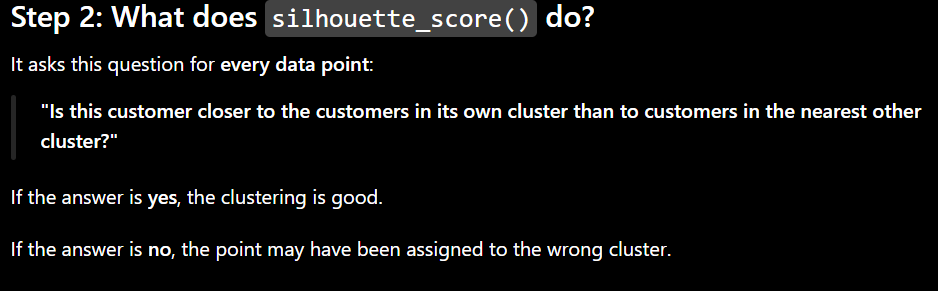

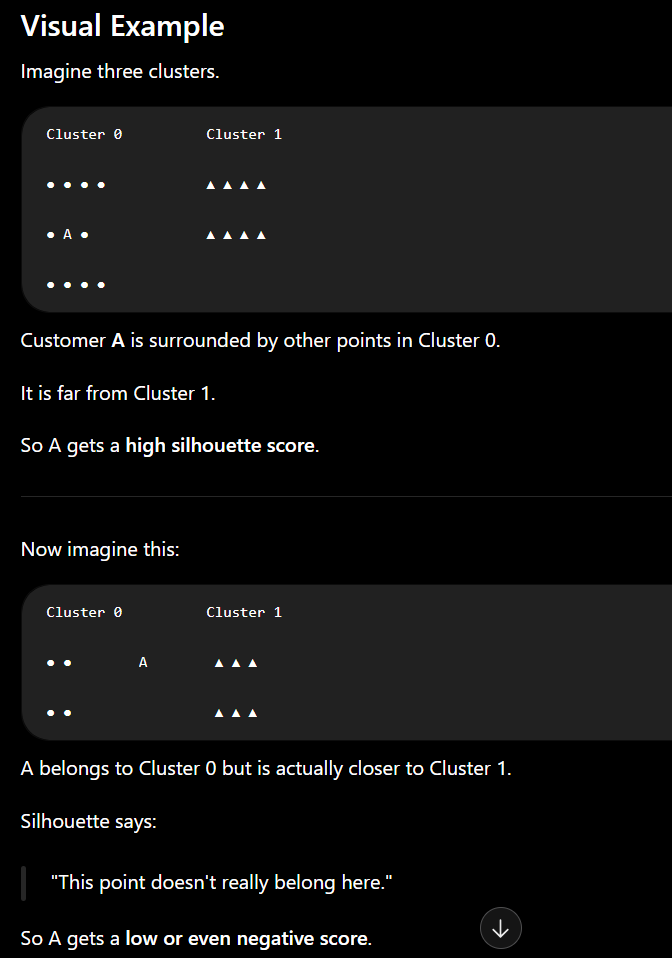

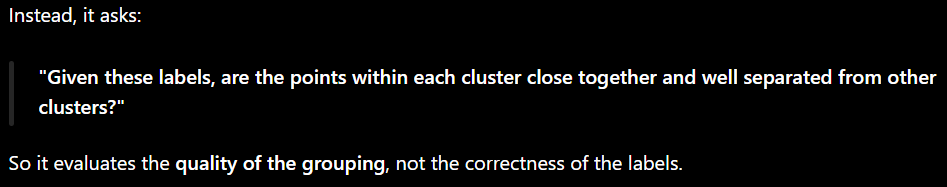

In [50]:

# Silhouette Score


# Calculate the Silhouette Score
silhouette = silhouette_score(df_scaled, kmeans.labels_)

print("Silhouette Score :", round(silhouette,3))

Silhouette Score : 0.261


In [32]:

# Import DBSCAN

from sklearn.cluster import DBSCAN

In [33]:

# Experiment with Different DBSCAN Parameters


# The performance of DBSCAN depends on two parameters:
# 1. eps - Radius around each data point
# 2. min_samples - Minimum number of points required to form a cluster

parameters = [
    (0.8, 5),
    (1.0, 5),
    (1.2, 5),
    (1.5, 5),
    (1.5, 10)
]

print("DBSCAN Parameter Tuning Results\n")

for eps, min_samples in parameters:

    db = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = db.fit_predict(df_scaled)

    # Skip invalid clustering results
    if len(set(labels)) <= 1:
        continue

    # Remove noise points
    mask = labels != -1

    # Need at least 2 clusters after removing noise
    if len(set(labels[mask])) < 2:
        continue

    score = silhouette_score(
        df_scaled[mask],
        labels[mask]
    )

    print(
        f"eps = {eps}, min_samples = {min_samples} --> "
        f"Clusters = {len(set(labels)) - (1 if -1 in labels else 0)}, "
        f"Silhouette Score = {score:.3f}"
    )

DBSCAN Parameter Tuning Results

eps = 0.8, min_samples = 5 --> Clusters = 8, Silhouette Score = 0.227
eps = 1.0, min_samples = 5 --> Clusters = 6, Silhouette Score = 0.282
eps = 1.2, min_samples = 5 --> Clusters = 5, Silhouette Score = 0.271
eps = 1.5, min_samples = 5 --> Clusters = 5, Silhouette Score = 0.294
eps = 1.5, min_samples = 10 --> Clusters = 3, Silhouette Score = 0.298


In [34]:

# Build the DBSCAN Model


# eps controls the neighborhood radius.
# min_samples is the minimum number of nearby
# points required to form a cluster.

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

# Train the model
dbscan.fit(df_scaled)

DBSCAN(eps=1.5)

In [51]:

# Cluster Labels


dbscan.labels_

array([0, 0, 0, ..., 1, 0, 0])

In [52]:

# Store DBSCAN Clusters


df["DBSCAN_Cluster"] = dbscan.labels_

df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,Cluster,DBSCAN_Cluster
0,28143,0,1,1,1,174,1,0,0,7000,0,2,0
1,19244,0,1,1,1,215,2,0,0,6968,0,2,0
2,41354,0,1,1,1,4123,4,0,0,7034,0,2,0
3,14776,0,1,1,1,500,1,0,0,6952,0,2,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1,1,1


In [53]:

# Number of Customers in Each DBSCAN Cluster


df["DBSCAN_Cluster"].value_counts()

,count
DBSCAN_Cluster,
0,2411
1,1250
-1,310
2,15
3,8
4,5


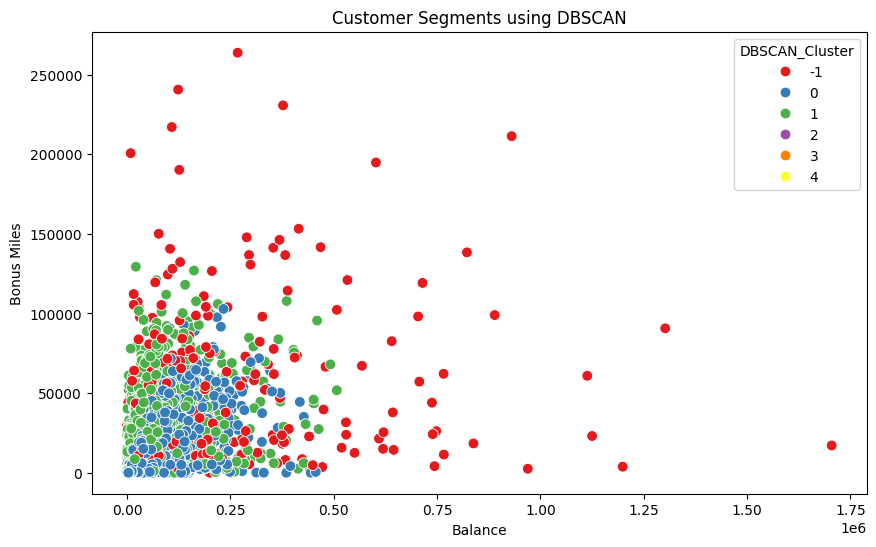

In [38]:

# Visualize DBSCAN Clusters


plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Balance",
    y="Bonus_miles",
    hue="DBSCAN_Cluster",
    palette="Set1",
    s=60
)

plt.title("Customer Segments using DBSCAN")
plt.xlabel("Balance")
plt.ylabel("Bonus Miles")

plt.show()

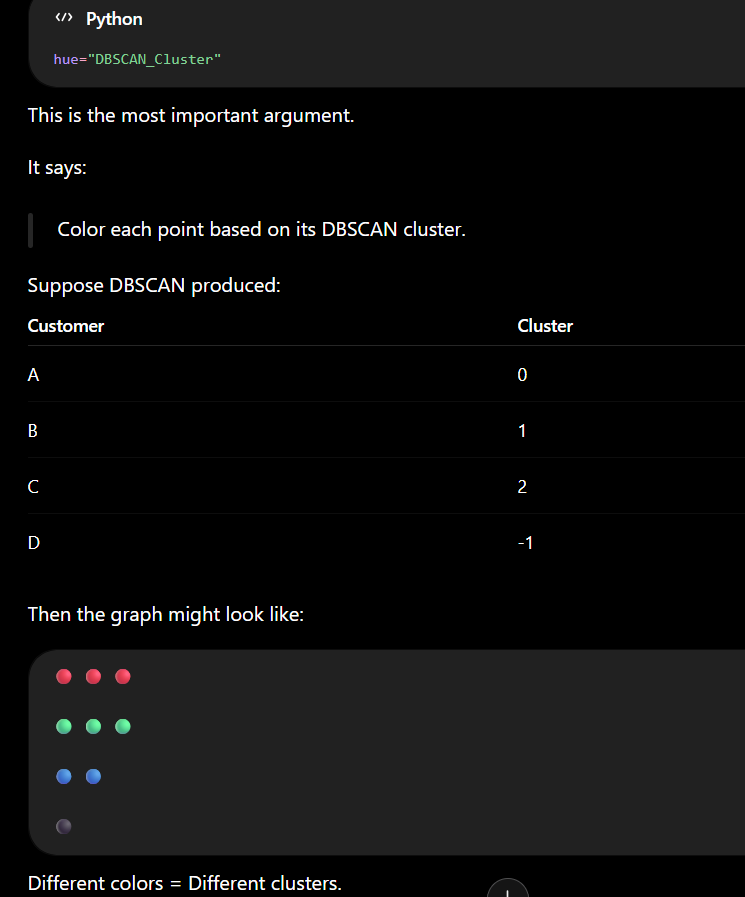

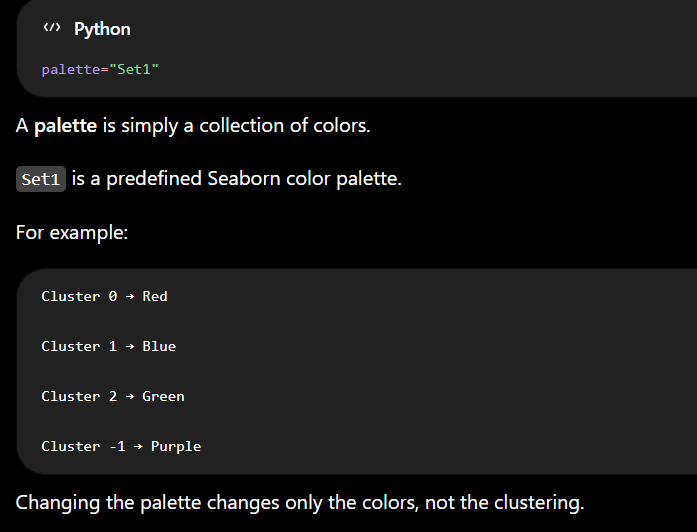

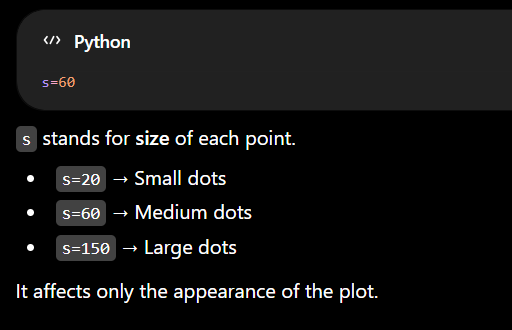

In [39]:

# Number of Clusters Found


# Count all unique clusters

print("Unique Clusters :")

print(df["DBSCAN_Cluster"].unique())

print()

print("Total Clusters (excluding noise):")

print(len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0))

Unique Clusters :
[ 0  1 -1  2  3  4]

Total Clusters (excluding noise):
5


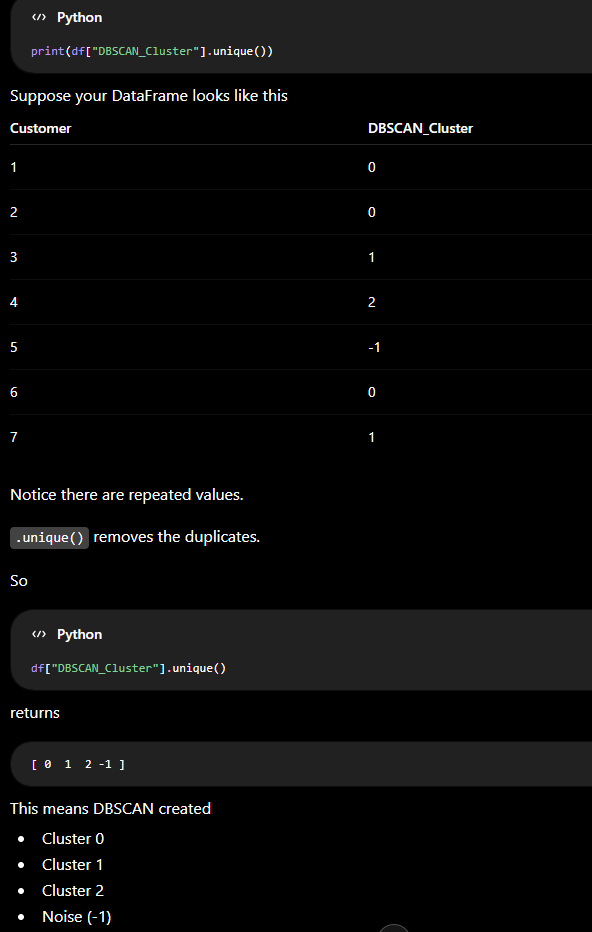

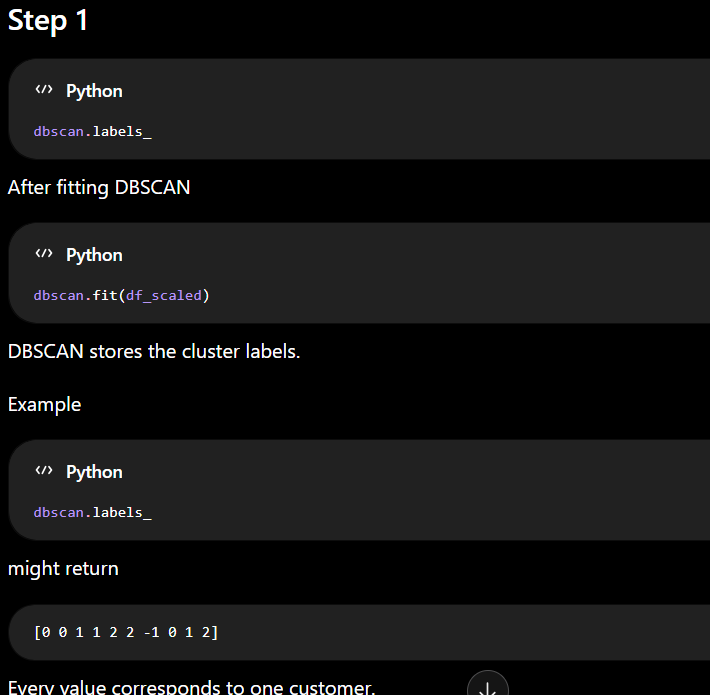

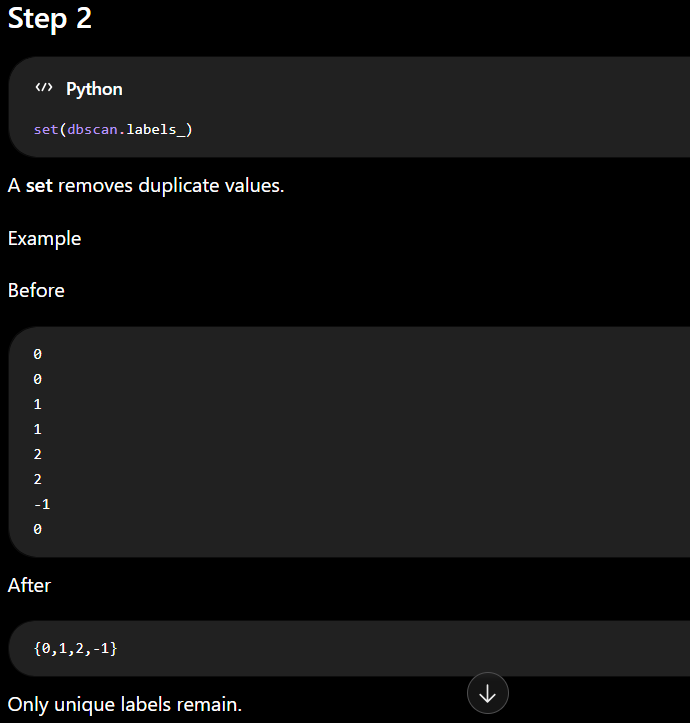

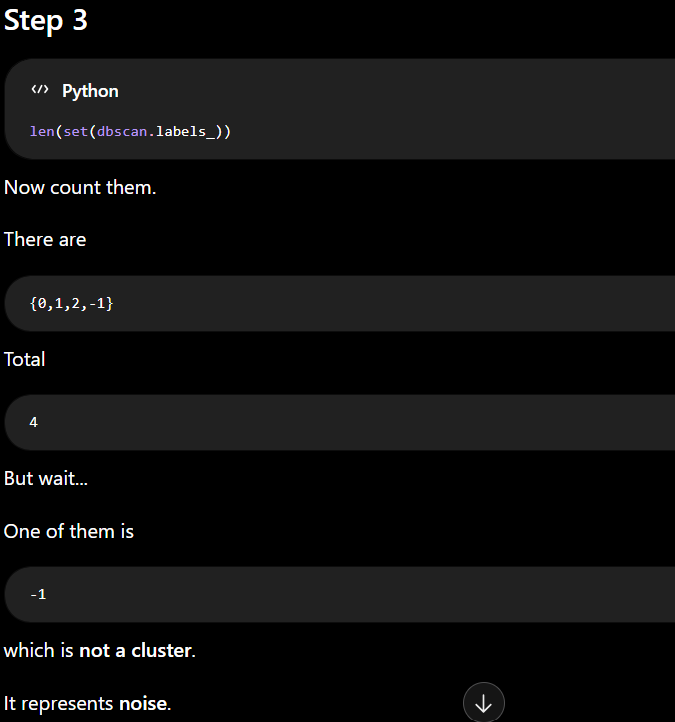

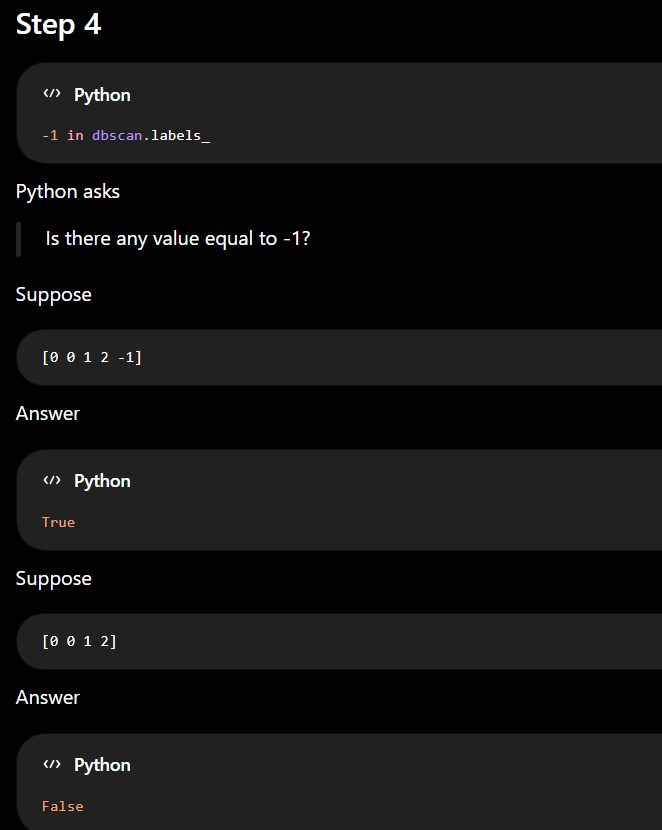

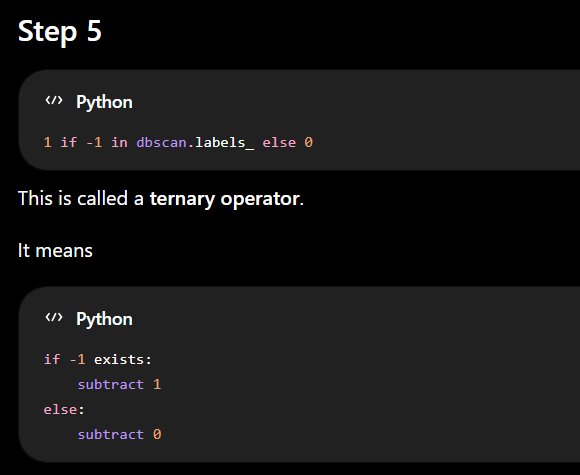

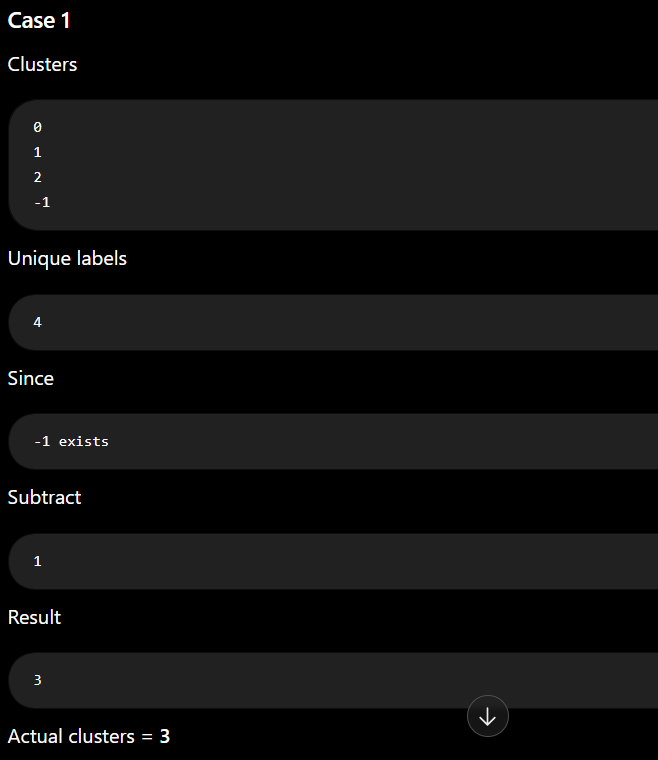

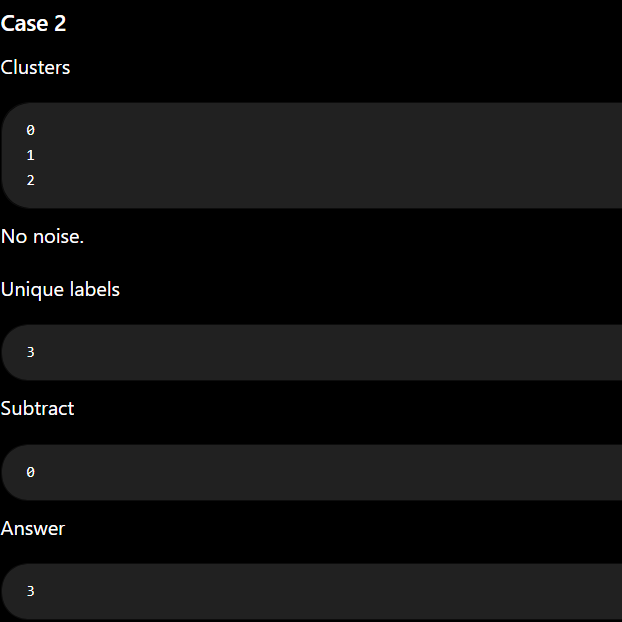

DBSCAN assigns the label -1 to observations that do not belong to any cluster. These are considered noise points, not actual clusters.

 Therefore, when counting the number of clusters, we subtract 1 if the -1 label exists so that only the real clusters are counted.

In [54]:

# Silhouette Score for DBSCAN

# Silhouette Score cannot properly evaluate noise points (-1), so we remove them before calculating the score.

# Remove Noise Points

mask = dbscan.labels_ != -1

# Calculate Silhouette Score

silhouette_dbscan = silhouette_score(
    df_scaled[mask],
    dbscan.labels_[mask]
)

print("DBSCAN Silhouette Score :", round(silhouette_dbscan,3))

DBSCAN Silhouette Score : 0.294


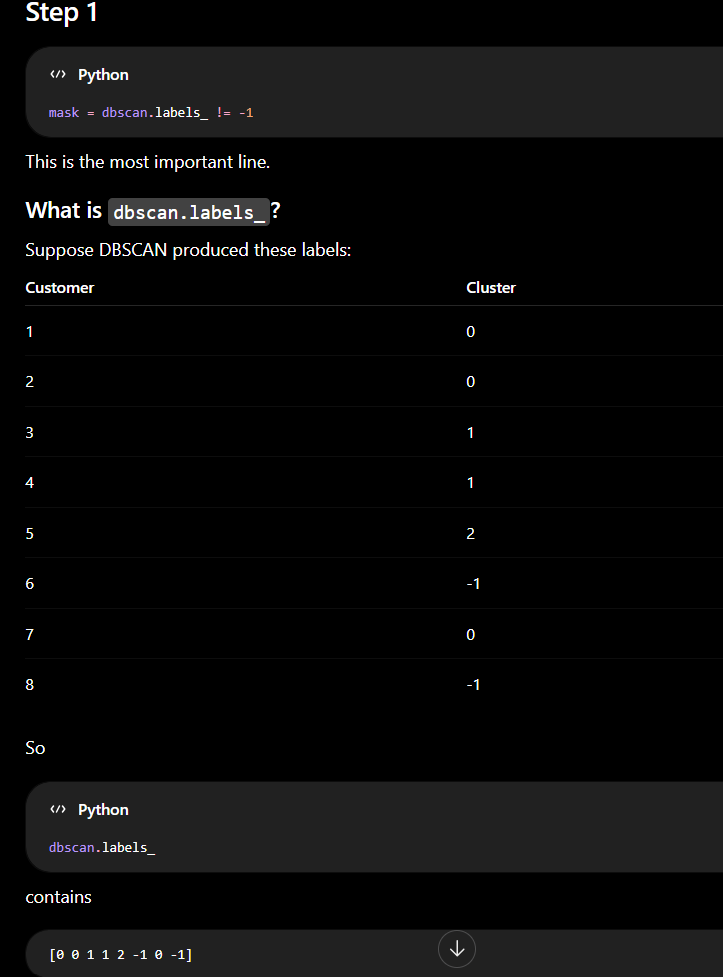

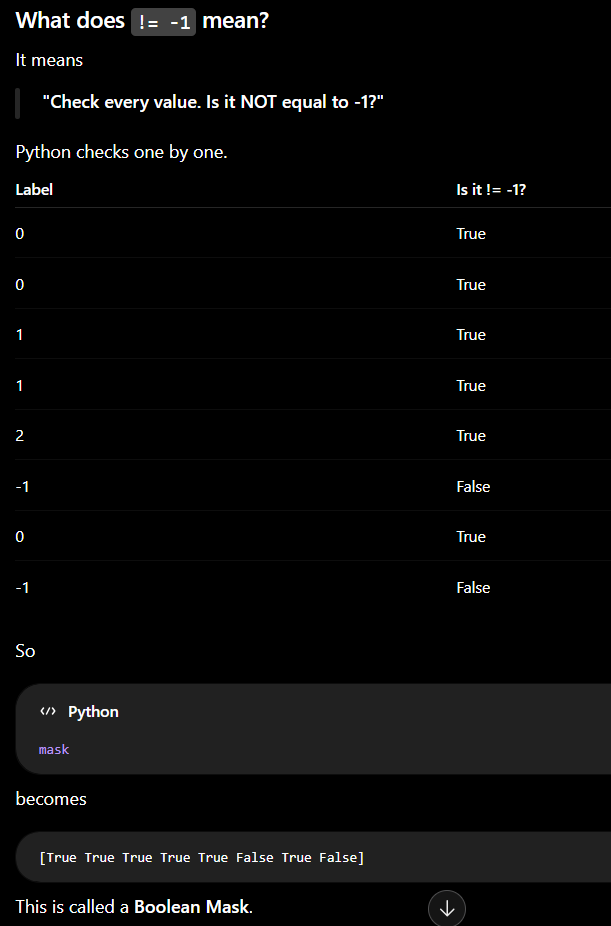

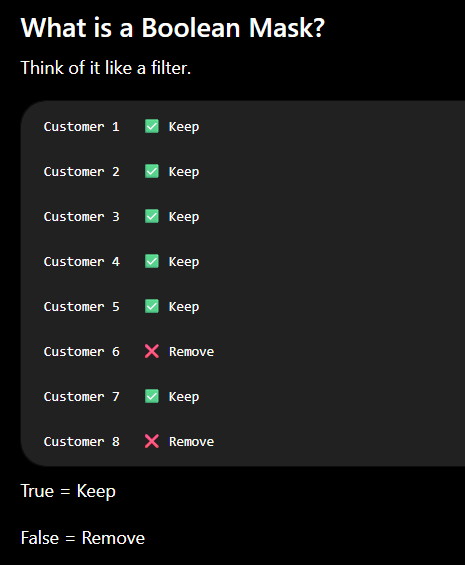

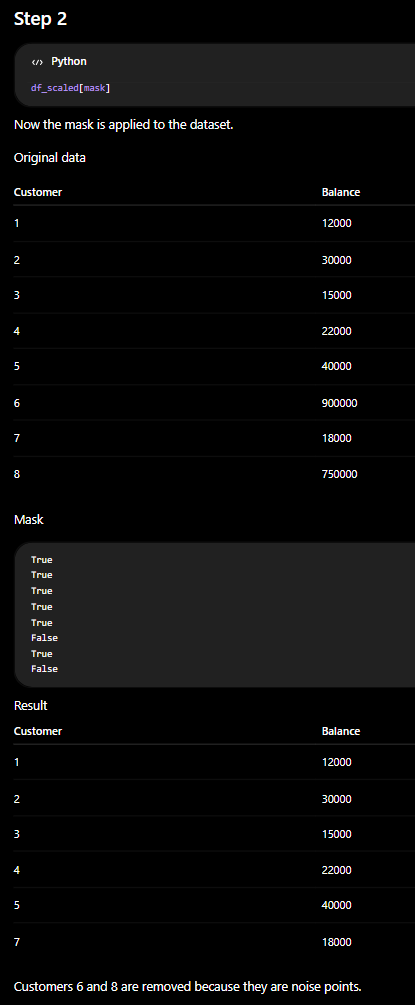

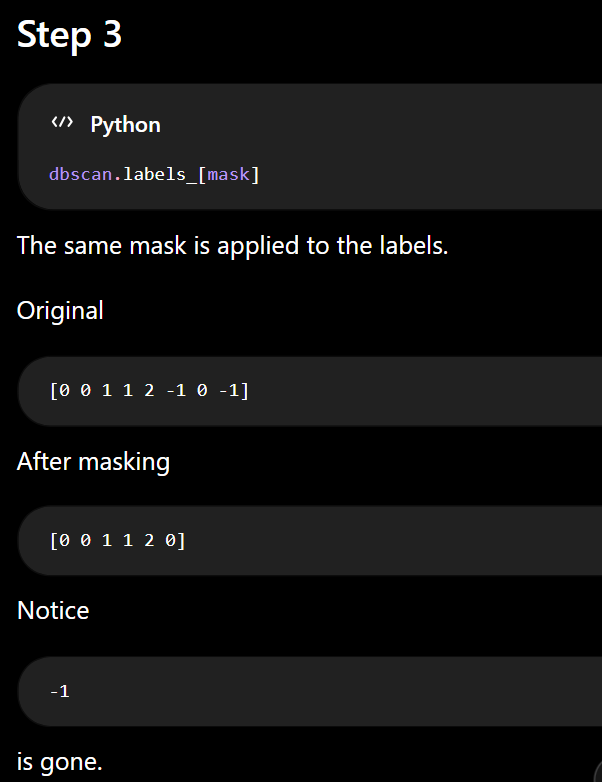

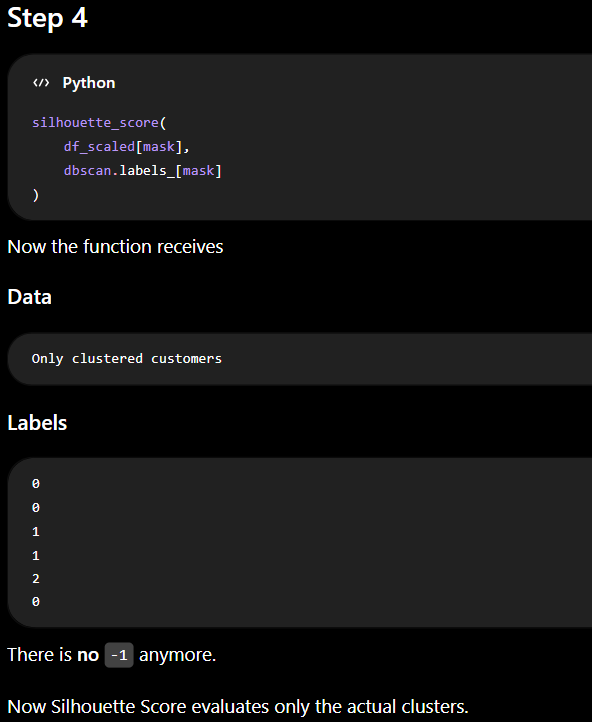

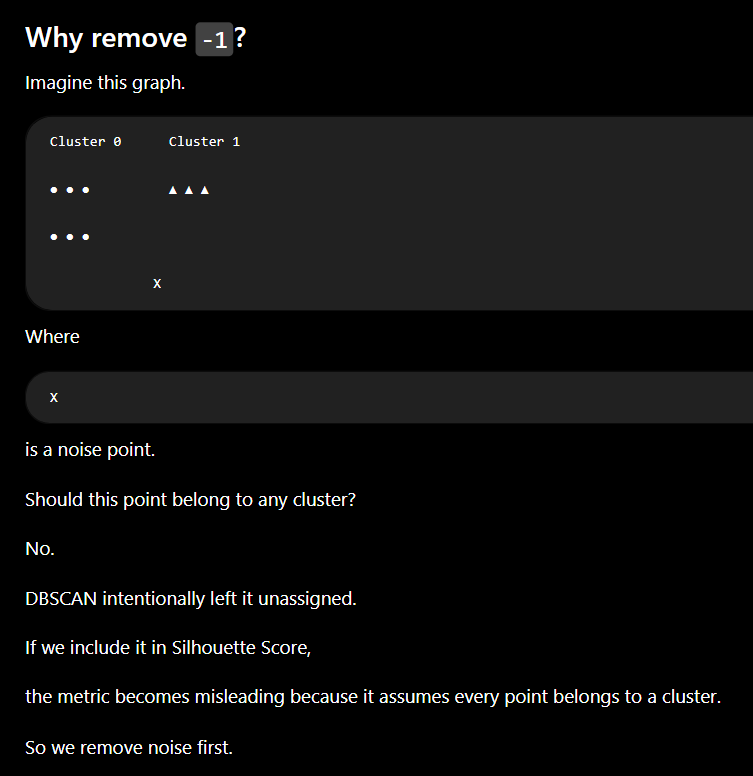

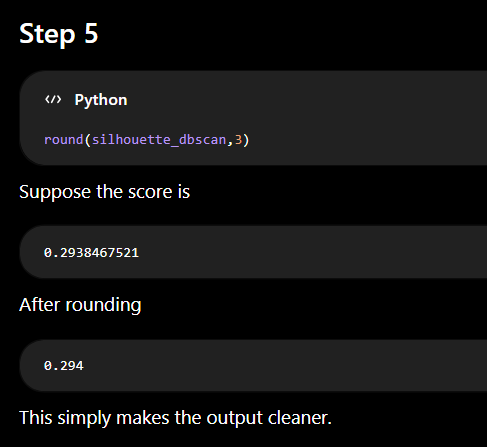

Because -1 represents noise points, not actual clusters. The Silhouette Score is designed to evaluate the quality of cluster assignments, so including noise points would distort the evaluation.

Therefore, we first filter out the noise using a Boolean mask and then calculate the score only on the clustered observations.

In [41]:

# Model Comparison


comparison = pd.DataFrame({

    "Algorithm":[
        "K-Means",
        "DBSCAN"
    ],

    "Number of Clusters":[
        len(np.unique(kmeans.labels_)),
        len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
    ],

    "Silhouette Score":[
        round(silhouette,3),
        round(silhouette_dbscan,3)
    ]

})

comparison

,Algorithm,Number of Clusters,Silhouette Score
0,K-Means,4,0.191
1,DBSCAN,5,0.294



 Why did DBSCAN perform better?

DBSCAN achieved a higher Silhouette Score (0.294)

compared to K-Means (0.191).

It also identified 310 noise points instead of
forcing every customer into a cluster.

Therefore, DBSCAN produced more meaningful
customer groups for this dataset.

# Final Conclusion

• Data preprocessing and feature scaling were successfully performed.

• K-Means identified 4 customer clusters.

• DBSCAN identified 5 clusters and 310 noise points.

• K-Means Silhouette Score = 0.191

• DBSCAN Silhouette Score = 0.294

• DBSCAN performed better than K-Means for this dataset.

• Customer segmentation helps airlines understand customer behavior
  and improve marketing strategies, loyalty programs, and customer retention.